https://rhodesmill.org/skyfield/toc.html

In [284]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
%matplotlib widget

import scipy
import skyfield as sf
from skyfield.api import *
import skyfield.positionlib as poslib
from tle_parser import TLE
from datetime import datetime, timezone
from multilateration import solve_multilateration

In [394]:
plantes = load('de421.bsp')
earth = plantes['earth']
agh_krk = earth + wgs84.latlon(50.06767 * N, 19.91516 * E)

ts = load.timescale()

time_0 = datetime(2026, 4, 25, 12, 0, 0, tzinfo=timezone.utc)
time_1 = datetime(2026, 4, 25, 21, 20, 0, tzinfo=timezone.utc)
time_2 = datetime(2026, 4, 25, 21, 30, 0, tzinfo=timezone.utc)

tle = TLE.from_orbital_parameters(
epoch=time_0,
inclination_deg=90.0,
raan_deg=15,
eccentricity=0.0005,
argument_of_perigee_deg=80.0,
mean_anomaly_deg=20.0,
mean_motion_rev_per_day=15.5
)
  
satellite = EarthSatellite(tle.line1, tle.line2, f'Dummy Sat', ts)
t = ts.linspace(ts.from_datetime(time_1), ts.from_datetime(time_2), 1000)  # 1000 time points over the next hour

In [395]:
agh_lat_lon = (50.06767 * N, 19.91516 * E)
gda_lat_lon = (54.3520 * N, 18.6466 * E)
agh_loc = wgs84.latlon(agh_lat_lon[0], agh_lat_lon[1])
gda_loc = wgs84.latlon(gda_lat_lon[0], gda_lat_lon[1])

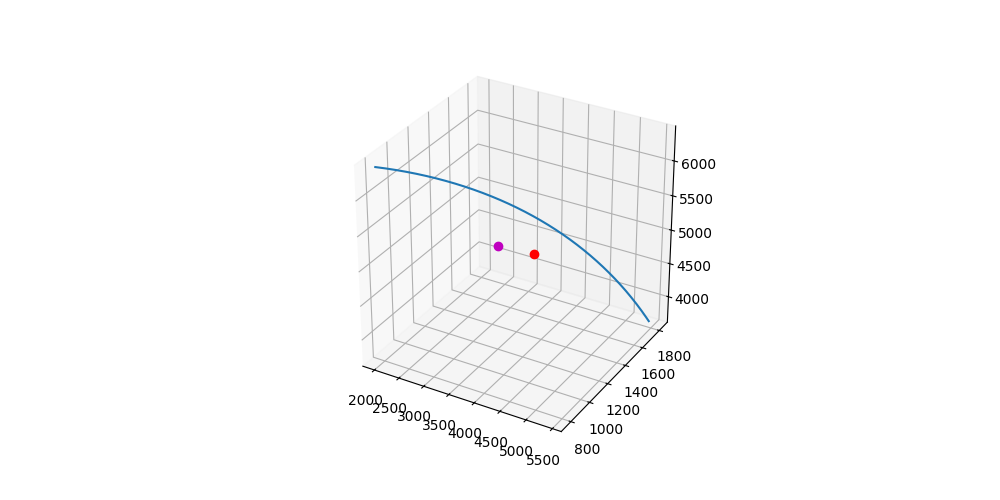

In [396]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='3d')
ax.set_aspect('equal')
sat_xyz = satellite.at(t).subpoint().itrs_xyz.km
agh_xyz = agh_loc.itrs_xyz.km
gda_xyz = gda_loc.itrs_xyz.km
ax.plot(sat_xyz[0], sat_xyz[1], sat_xyz[2], label='Satellite Path')
ax.plot(agh_xyz[0], agh_xyz[1], agh_xyz[2], 'ro', label='AGH Kraków')
ax.plot(gda_xyz[0], gda_xyz[1], gda_xyz[2], 'mo', label='Gdańsk')

In [435]:
c = 299792.458  # Speed of light in km/s

stations = [agh_loc, gda_loc]
station_names = ['AGH Kraków', 'Gdańsk']

rs = satellite.at(t).position.km
vs = satellite.at(t).velocity.km_per_s
ra = agh_loc.at(t).position.km
rb = gda_loc.at(t).position.km
ras = rs - ra
rbs = rs - rb
ras_unit = ras / np.linalg.norm(ras, axis=0)
rbs_unit = rbs / np.linalg.norm(rbs, axis=0)
vas = np.vecdot(ras_unit, vs, axis=0)
vbs = np.vecdot(rbs_unit, vs, axis=0)

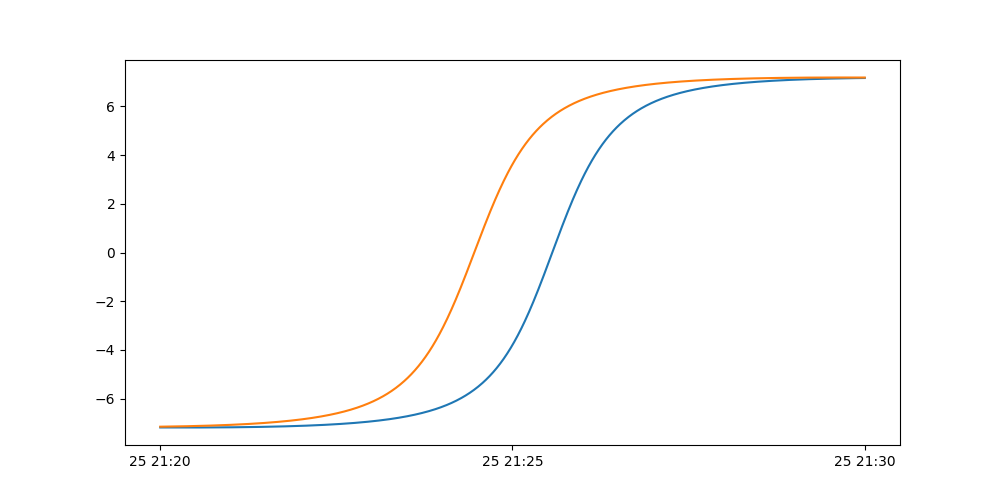

In [436]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)
ax.plot(t.utc_datetime(), vas)
ax.plot(t.utc_datetime(), vbs)